In [1]:
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt

files = {

    "dark": Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.29/7.29 dark/7.29 dark_MMStack_Pos0.ome.tif"),

    "sample0":   Path("/Users/sunxiaoyuamanda/Desktop/summer project/9.5/9.5 10x stain flo/9.5 10x stain flo_MMStack_Pos0.ome.tif")}


for key, path in files.items():
    print(f"{key}: exists={path.exists()}")

dark: exists=True
sample0: exists=True


In [2]:
def load_ome_tif(path):
    """
    Read OME-TIFF and return float64 image or stack.

    Returns
    -------
    img : np.ndarray
        - 2D: shape (H, W)
        - 3D: shape (N, H, W)
    """
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    arr = tifffile.imread(path)
    arr = np.squeeze(arr)

    print(f"{path.name}: shape={arr.shape}, dtype={arr.dtype}")

    if arr.ndim == 2:
        img = arr
    elif arr.ndim == 3:
        # keep the full stack, e.g. (16, H, W)
        print(f"Info: using full stack with shape {arr.shape}")
        img = arr
    else:
        raise ValueError(f"Unsupported image shape: {arr.shape}")

    return img.astype(np.float64)

9.5 10x stain flo_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
Loaded image shape: (2048, 2432)
min/max: 0.0 539.0


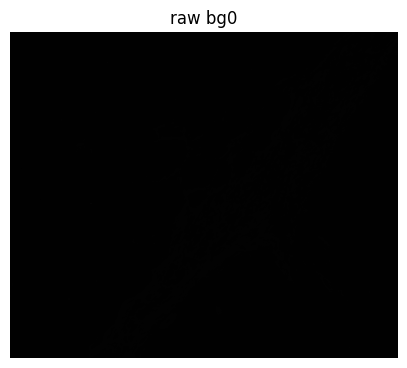

In [3]:
raw_test = load_ome_tif(files["sample0"])

print("Loaded image shape:", raw_test.shape)
print("min/max:", raw_test.min(), raw_test.max())

plt.figure(figsize=(5, 5))
plt.imshow(raw_test, cmap="gray")
plt.title("raw bg0")
plt.axis("off")
plt.show()

In [4]:
def split_pol_channels(raw):
    """
    Split raw polarization mosaic using pattern:
        [ I0,   I135 ]
        [ I45,  I90  ]

    Supports:
        - 2D input: (H, W)
        - 3D stack: (N, H, W)

    Returns
    -------
    I0, I45, I90, I135 : np.ndarray
        - For 2D input: shape (H/2, W/2)
        - For 3D input: shape (N, H/2, W/2)
    """
    if raw.ndim == 2:
        I0   = raw[0::2, 0::2]
        I135 = raw[0::2, 1::2]
        I45  = raw[1::2, 0::2]
        I90  = raw[1::2, 1::2]

    elif raw.ndim == 3:
        I0   = raw[:, 0::2, 0::2]
        I135 = raw[:, 0::2, 1::2]
        I45  = raw[:, 1::2, 0::2]
        I90  = raw[:, 1::2, 1::2]

    else:
        raise ValueError(f"Expected 2D or 3D image, got shape {raw.shape}")

    return I0, I45, I90, I135

9.5 10x stain flo_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
7.29 dark_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
Inspecting: sample0
I0 shape   : (1024, 1216)
I45 shape  : (1024, 1216)
I90 shape  : (1024, 1216)
I135 shape : (1024, 1216)


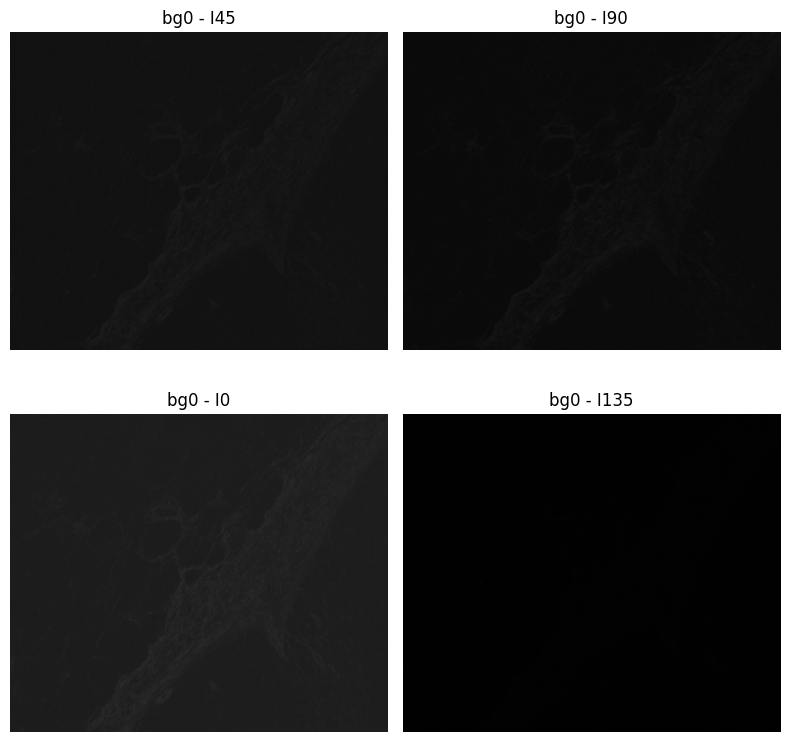

In [5]:
inspect_key = "sample0"
raw_inspect = load_ome_tif(files[inspect_key])-load_ome_tif(files['dark'])

I0_bg, I45_bg, I90_bg, I135_bg = split_pol_channels(raw_inspect)

print(f"Inspecting: {inspect_key}")
print("I0 shape   :", I0_bg.shape)
print("I45 shape  :", I45_bg.shape)
print("I90 shape  :", I90_bg.shape)
print("I135 shape :", I135_bg.shape)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].imshow(I45_bg, cmap="gray")
axes[0, 0].set_title("bg0 - I45")

axes[0, 1].imshow(I90_bg, cmap="gray")
axes[0, 1].set_title("bg0 - I90")

axes[1, 0].imshow(I0_bg, cmap="gray")
axes[1, 0].set_title("bg0 - I0")

axes[1, 1].imshow(I135_bg, cmap="gray")
axes[1, 1].set_title("bg0 - I135")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
def stokes_from_raw(raw, eps=1e-12):
    """
    Compute Stokes maps from raw image or raw stack.

    Supports
    --------
    raw : np.ndarray
        - 2D: (H, W)
        - 3D: (N, H, W)

    Returns
    -------
    dict of np.ndarray
        Keys: "I0", "I45", "I90", "I135", "S0", "S1", "S2", "s1", "s2"

        - For 2D input: each output has shape (H/2, W/2)
        - For 3D input: each output has shape (N, H/2, W/2)
    """
    I0, I45, I90, I135 = split_pol_channels(raw)
    

    S0 = 0.5 * (I0 + I45 + I90 + I135)
    S1 = I0 - I90
    S2 = I45 - I135
    s1 = (I0 - I90)/(I0+I90)
    s2= (I45 - I135)/(I45 + I135)

    return {
        "I0": I0,
        "I45": I45,
        "I90": I90,
        "I135": I135,
        "S0": S0,
        "S1": S1,
        "S2": S2,
        "s1": s1,
        "s2": s2,
    }

In [7]:
import os
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt


In [8]:
raw_test = load_ome_tif(files["sample0"])-load_ome_tif(files['dark']) 
S_out=stokes_from_raw(raw_test)
print("S_out shape:", S_out["S0"].shape)

9.5 10x stain flo_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
7.29 dark_MMStack_Pos0.ome.tif: shape=(2048, 2432), dtype=uint16
S_out shape: (1024, 1216)


/var/folders/96/w50s3ss53xb0qm81mw4d4kbc0000gn/T/ipykernel_11310/2664278645.py:25: RuntimeWarning: divide by zero encountered in divide
  s1 = (I0 - I90)/(I0+I90)
/var/folders/96/w50s3ss53xb0qm81mw4d4kbc0000gn/T/ipykernel_11310/2664278645.py:25: RuntimeWarning: invalid value encountered in divide
  s1 = (I0 - I90)/(I0+I90)
/var/folders/96/w50s3ss53xb0qm81mw4d4kbc0000gn/T/ipykernel_11310/2664278645.py:26: RuntimeWarning: divide by zero encountered in divide
  s2= (I45 - I135)/(I45 + I135)
/var/folders/96/w50s3ss53xb0qm81mw4d4kbc0000gn/T/ipykernel_11310/2664278645.py:26: RuntimeWarning: invalid value encountered in divide
  s2= (I45 - I135)/(I45 + I135)


In [9]:
save_dir = "9.5 sample 4x flo"
os.makedirs(save_dir, exist_ok=True)

print("Save directory:", os.path.abspath(save_dir))

Save directory: /Users/sunxiaoyuamanda/Desktop/summer project/9.5 sample 4x flo


In [10]:
bright_field = S_out["S0"]
print("bright_field shape:", bright_field.shape)

bright_field shape: (1024, 1216)


In [11]:
bright_field_filename = os.path.join(save_dir, "wide field.tif")
def to_float32_image(img):
    return np.asarray(img, dtype=np.float32)

tiff.imwrite(bright_field_filename, to_float32_image(bright_field))

print("Saved bright field TIFF:", bright_field_filename)

Saved bright field TIFF: 9.5 sample 4x flo/wide field.tif
